In [1]:
import yfinance as yf
import pandas as pd

vix = yf.download(
    "^VIX",
    period="1y",
    auto_adjust=True
)

vix.columns = vix.columns.get_level_values(0)

vix.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-08-06,16.77,17.879999,16.559999,17.219999,0
2025-08-07,16.57,17.639999,15.980000,16.410000,0
2025-08-08,15.15,16.520000,15.150000,16.480000,0
2025-08-11,16.25,16.360001,15.520000,15.810000,0
2025-08-12,14.73,16.559999,14.660000,16.090000,0


In [2]:
spy = yf.download(
    "SPY",
    period="1y",
    auto_adjust=True
)

spy.columns = spy.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [3]:
common_dates = spy.index.intersection(vix.index)

spy = spy.loc[common_dates]
vix = vix.loc[common_dates]

In [4]:
spy_returns = spy["Close"].pct_change()

vix_returns = vix["Close"].pct_change()

In [5]:
spy_returns.head()

Date
2025-08-06         NaN
2025-08-07   -0.000838
2025-08-08    0.007797
2025-08-11   -0.001977
2025-08-12    0.010646
Name: Close, dtype: float64

In [6]:
vix_returns.head()

Date
2025-08-06         NaN
2025-08-07   -0.011926
2025-08-08   -0.085697
2025-08-11    0.072607
2025-08-12   -0.093538
Name: Close, dtype: float64

In [7]:
returns = (
    pd.DataFrame({
        "SPY": spy_returns,
        "VIX": vix_returns
    })
    .dropna()
)

In [8]:
correlation = returns["SPY"].corr(returns["VIX"])

print(correlation)

-0.820508113615443


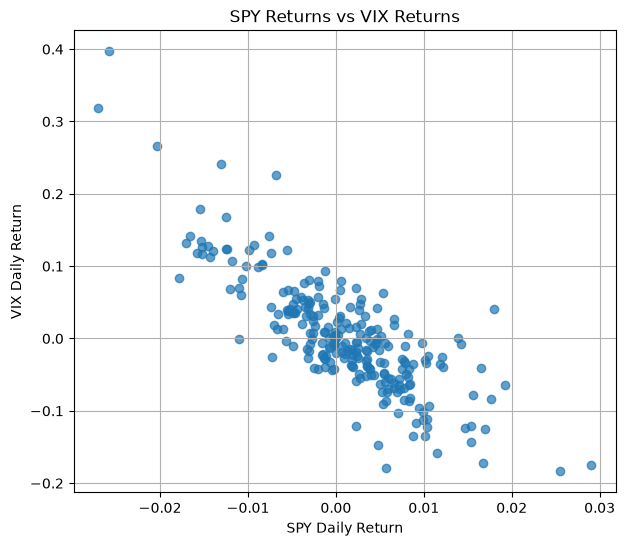

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(
    returns["SPY"],
    returns["VIX"],
    alpha=0.7
)

plt.xlabel("SPY Daily Return")
plt.ylabel("VIX Daily Return")
plt.title("SPY Returns vs VIX Returns")
plt.grid(True)

plt.savefig(
    "../report/SPY_VIX_Scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()